In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
import datetime
from scipy.ndimage import rotate
import time
from matplotlib.patches import FancyBboxPatch
from scipy.ndimage import gaussian_filter
import colormaps as cmaps 
import matplotlib.ticker as mticker
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
#%run GEOS5functions.py
%matplotlib inline 

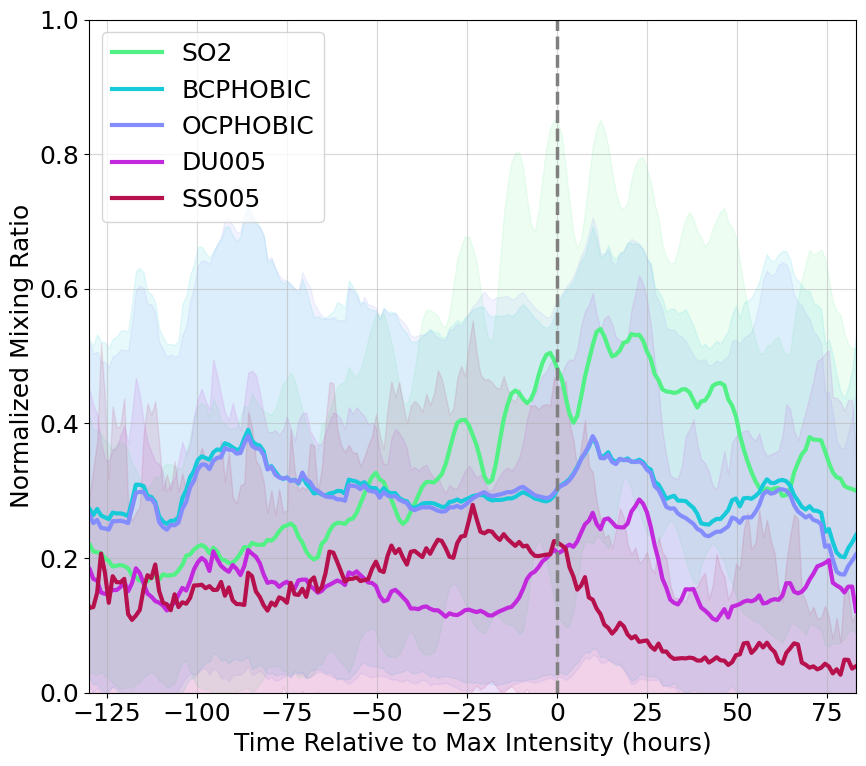

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl

mpl.rcParams.update({'font.size': 18})  

# --- Settings ---
npz_dir = '.'  # Folder containing .npz files
lev = 39  # Specific pressure level
norm_method = 'minmax'

# --- Define variable names ---
#variables = ['so4', 'so2', 'bcphilic', 'bcphobic', 'ocphilic', 'ocphobic', 'du001', 'du005', 'ss001', 'ss005']
#variables = ['so4', 'bcphilic', 'ocphilic', 'du001',  'ss001']
variables = [ 'so2', 'bcphobic', 'ocphobic', 'du005', 'ss005']



# --- Define color groups ---
reds = cmaps.neon_r # For the red group (note: cmaps.blues for previous blues)
blues = cmaps.neon_r	 # For the blue group (note: cmaps.reds for reds)

color_map = {
    # Shades from cmaps.blues (for previous reds)
    'so4': reds(0.1),
    'bcphilic': reds(0.3),
    'ocphilic': reds(0.5),
    'du001': reds(0.7),
    'ss001': reds(0.9),
    
    # Shades from cmaps.reds (for previous blues)
    'so2': blues(0.1),
    'bcphobic': blues(0.3),
    'ocphobic': blues(0.5),
    'du005': blues(0.7),
    'ss005': blues(0.9)
    
}

line_styles = {
    'so2': '-',
    'bcphobic': '--',
    'ocphobic': '-.',
    'du005': ':',
    'ss005': '-',
}

# --- Setup plot ---
plt.figure(figsize=(9, 8))

# --- Loop and plot ---
for var in variables:
    filename = f"{var}_timed_{norm_method}_normalized_data_lev{lev}_cat3to5.npz"
    filepath = os.path.join(npz_dir, filename)
    
    if not os.path.exists(filepath):
        print(f"Skipping: {filename} (not found)")
        continue

    data = np.load(filepath)
    
    common_t = data['common_t']
    norm_mean = data['norm_mean']
    norm_std = data['norm_std']
    
    color = color_map.get(var, 'gray')  # default to gray if not mapped
    linestyle = line_styles.get(var, '-')
    
    # Plot line + std shading
    plt.plot(common_t, norm_mean, label=var.upper(), lw=3, 
             color=color) # , linestyle=linestyle
    plt.fill_between(common_t, norm_mean - norm_std, norm_mean + norm_std, alpha=0.1, color=color)

# --- Styling ---
plt.axvline(0, color='grey', linestyle='--', linewidth=2.5, alpha=1)

plt.xlabel('Time Relative to Max Intensity (hours)')

if norm_method in ["max", "baseline", "t0"]:
    plt.ylim(0, 2)
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ylabel = f'Normalized Concentration Ratio ({norm_method})'
elif norm_method == "zscore":
    plt.ylim(-3, 3)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ylabel = 'Z-score Normalized Concentration'
elif norm_method == "minmax":
    plt.ylim(0, 1)
    ylabel = 'Normalized Mixing Ratio'
elif norm_method == "rolling":
    plt.ylim(0.5, 1.5)
    plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ylabel = 'Normalized to Rolling Average'

plt.ylabel(ylabel)
plt.xlim(-130, 83)
plt.grid(True, alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
#plt.title(f'Normalized Aerosol Tracers (Level {lev}, {norm_method})')
#plt.savefig(f'combined_normalized_profiles_{norm_method}_lev{lev}_cat3to5.png')
plt.savefig(f'combined_normalized_profiles_phobics_{norm_method}_lev{lev}_cat3to5.png')
plt.show()
